##**SVM MODEL**

In this whole process, 21 land cover categories from **UC Merced Land Use dataset** and there **corresponding labels** are used. After loading they are sfuffeled and splited into 80% training, 10% validation and 10% testing data.Later to use them to train on CNN, normalized by dividing with 255.

SVM model is trained on 5 chosen classes and their data is filtered using **n.isin** (creats boolean mask where each element is true if the corresponding label in trained data is one of the chosen class otherwise false) and **n.where** (function which identifies the indices of elements in train data that satisfy the condition in the boolean mask).

To optimize the model's performance, conducted hyperpatameter tuning using **GridSearchCV**.This evalueates different combinations of the **regularization paramete**(c) and **kernel type** (linear or rbf) through cross validation.

Confusion matrix is calculated to compare truth and predicted values of test data and visualized as a heatmap using **seaborn**


Images Shape: (2100, 61, 61, 3)

Labels Shape: (2100, 1)

Best Parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Best Score for SVM: 0.6973964762652901


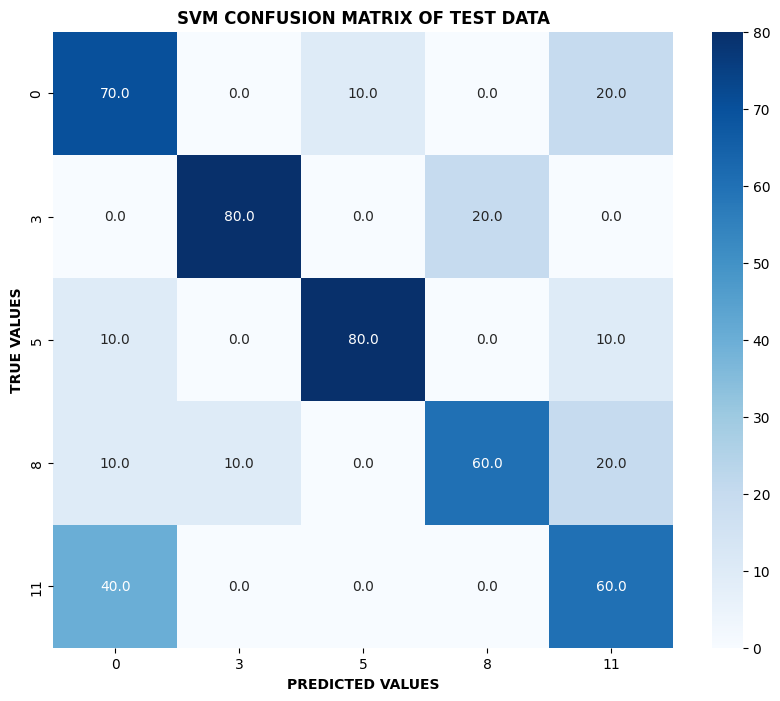


RESULTS OF SVM

Training Accuracy: 99.5

Validation Accuracy: 74.0

Test Accuracy: 70.0


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#load UC Merced Land datasets along with their labels
LandData = np.load('DS_Xdata.npy')
LandLable = np.load('Ydata.npy')

#visualize the shape of loaded datas
print("\nImages Shape:", LandData.shape)
print("\nLabels Shape:", LandLable.shape)

#shuffel and split the data into train, validation and test
LandData_train, LandData_temp, LandLable_train, LandLable_temp = train_test_split(LandData, LandLable, test_size=0.2, random_state=42, stratify=LandLable)                            #training 80%, temperory 20%
LandData_val, LandData_test, LandLable_val, LandLable_test = train_test_split(LandData_temp, LandLable_temp, test_size=0.5, random_state=42, stratify=LandLable_temp)                      # temperor 20% - validation 10%, test 10%                     # temperor 20% - validation 10%, test 10%                    # temperor 20% - validation 10%, test 10%

#later to train on CNN model normalize the data
LandDataNorm_Train = LandData_train / 255
LandDataNorm_Val= LandData_val / 255
LandDataNorm_Test= LandData_test / 255

# SVM(model 1)
chosen_classes = [0,3, 5, 8, 11]                                                #choose 5 specific classes of your choice

# using boolean masking (np.isin) to filter the data of choosen classes
#training data
LandDataTrain_5 = LandData_train[np.where(np.isin(LandLable_train, chosen_classes))]
LandLableTrain_5 = LandLable_train[np.where(np.isin(LandLable_train, chosen_classes))]

#validation data
LandDataVal_5 = LandData_val[np.where(np.isin(LandLable_val, chosen_classes))]
LandLableVal_5 = LandLable_val[np.where(np.isin(LandLable_val, chosen_classes))]

#testing data
LandDataTest_5 = LandData_test[np.where(np.isin(LandLable_test, chosen_classes))]
LandLableTest_5 = LandLable_test[np.where(np.isin(LandLable_test, chosen_classes))]

#normalize the data to train them on SVM model
normaliser = StandardScaler()
LandDataTrain_5_norm = normaliser.fit_transform(LandDataTrain_5.reshape(LandDataTrain_5.shape[0], -1))
LandDataVal_5_norm = normaliser.transform(LandDataVal_5.reshape(LandDataVal_5.shape[0], -1))
LandDataTest_5_norm = normaliser.transform(LandDataTest_5.reshape(LandDataTest_5.shape[0], -1))

#tuning the hyperparameters to avoid overfitting and underfitting
ParamGrid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
SvmGrid = GridSearchCV(SVC(), ParamGrid, cv=3)
SvmGrid.fit(LandDataTrain_5_norm, LandLableTrain_5)

#output the best parameters and their score
print("\nBest Parameters for SVM:", SvmGrid.best_params_)
print("\nBest Score for SVM:", SvmGrid.best_score_)

#train the model
SVM_Model= SvmGrid.best_estimator_
SVM_Model.fit(LandDataTrain_5_norm , LandLableTrain_5 )

#predicting values for normalised test data
SVM_predictions = SVM_Model.predict(LandDataTest_5_norm)
SVM_Model.score(LandDataTest_5_norm, LandLableTest_5)

#creating a confusion matrix for ground truth and predicted values of test data
ConfMatrix= confusion_matrix(LandLableTest_5, SVM_predictions )

#converting values in confusion matrix into percentage
ConfMatrix = ConfMatrix.astype('float') / ConfMatrix.sum(axis=1)[:, np.newaxis] * 100
ConfMatrix= np.nan_to_num(ConfMatrix, nan=0.0)

#visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(ConfMatrix, annot=True, fmt='.1f', cmap='Blues', xticklabels=chosen_classes, yticklabels=chosen_classes)
plt.xlabel('PREDICTED VALUES', fontweight='bold')
plt.ylabel('TRUE VALUES', fontweight='bold')
plt.title("SVM CONFUSION MATRIX OF TEST DATA", fontweight='bold')
plt.show()

#output the accuracy of training, validation and testing data
print("\nRESULTS OF SVM")
print("\nTraining Accuracy:", SVM_Model.score(LandDataTrain_5_norm , LandLableTrain_5 )*100)
print("\nValidation Accuracy:", SVM_Model.score(LandDataVal_5_norm, LandLableVal_5)*100)
print("\nTest Accuracy:", SVM_Model.score(LandDataTest_5_norm , LandLableTest_5)*100)

##**Feature extraction using Hog, Dimensionality reduction using PCA, Training on SVM**

This block of code shows how the HoG features are extracted, how dimentionality of data are reduced and how they are trained.

To extract meaningful feature, **HoG()** captures gradient-based patterns in images and apply to training, validation and testing datasets.

These feature's dimensionality are reduced using PCA by retaining **50 principle components** for computational efficiency and noise reduction.

Same like model 1 hyperparameter tuning is done but with 5 cross validation, trained on SVM modle, confusion matrix is calculated for test data.

Due to splitting the data using **train_test_split()** with **random state of 42**, a slight variation can arise in the values of accuracy for each time of running the code. This is because of **stratified splitting** where the class distributions are maintained across splits but might result in marginal diferences in data points allocated to each set.





/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam


Best Parameters:  {'C': 10, 'kernel': 'rbf'}

Best Cross-Validated Score:  0.5595238095238095


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


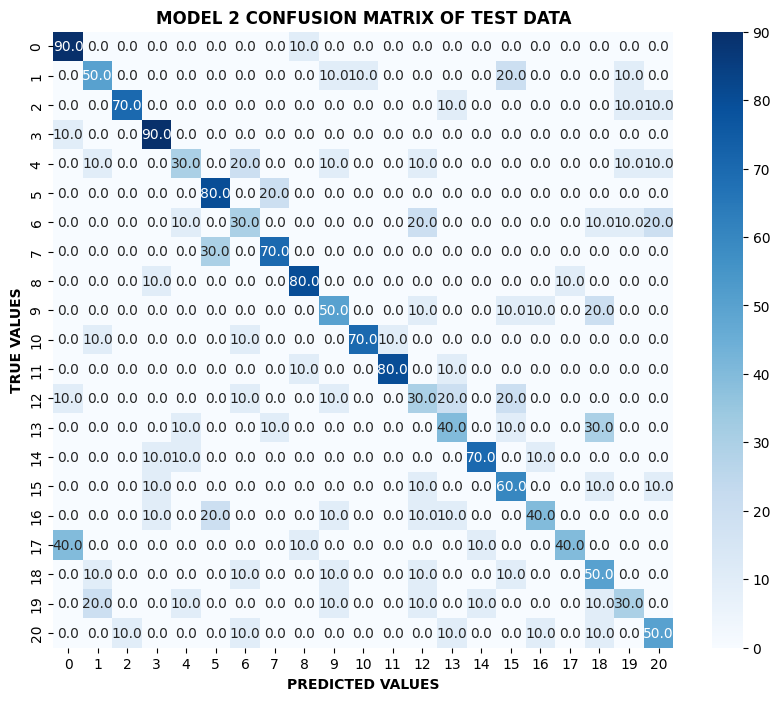

RESULTS OF HoG + PCA + SVM :

Training Accuracy:  99.22619047619048

Validation Accuracy:  56.666666666666664

Test Accuracy:  57.14285714285714


In [ ]:
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#function of HoG feature extraction
def HoGFeatures(images):
    features = [hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=8, visualize=False, channel_axis=-1) for img in images]
    return np.array(features)

#extracting the hog features for training, validation and testing data
LandDataHoG_train = HoGFeatures(LandData_train)                             #hog of train data
LandDataHoG_val = HoGFeatures(LandData_val)                                 #hog of validation data
LandDataHoG_test = HoGFeatures(LandData_test)                               #hog of test data

#using PCA for dimensionality reduction
pca = PCA(n_components=50)
LandDataPca_train = pca.fit_transform(LandDataHoG_train)
LandDataPca_val = pca.transform(LandDataHoG_val)
LandDataPca_test = pca.transform(LandDataHoG_test)

#tuning hyperparameters to avoid overfitting or underfitting
ParamGrid= {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}
SvmGrid_HoG = GridSearchCV(SVC(), ParamGrid, cv=5)
SvmGrid_HoG.fit(LandDataPca_train , LandLable_train)

#output the best parameters and their score
print("\nBest Parameters: ", SvmGrid_HoG.best_params_)
print("\nBest Cross-Validated Score: ", SvmGrid_HoG.best_score_)


#training SVM on PCA features
SVM_HoG = SvmGrid_HoG.best_estimator_
SVM_HoG.fit(LandDataPca_train, LandLable_train)

#predicting values for test  data
SVM_HoG_pred = SVM_HoG.predict(LandDataPca_test)
SVM_HoG.score(LandDataPca_test, LandLable_test)

#creating a confusion matrix between truth values and predicted values
ConfMatrix = confusion_matrix(LandLable_test, SVM_HoG_pred)

#converting the values in confusion matrix into percentage
ConfMatrix =ConfMatrix.astype('float') / ConfMatrix.sum(axis=1)[:, np.newaxis] * 100
ConfMatrix = np.nan_to_num(ConfMatrix, nan=0.0)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(ConfMatrix, annot=True, fmt='.1f', cmap='Blues', xticklabels=np.unique(LandLable), yticklabels=np.unique(LandLable))
plt.xlabel('PREDICTED VALUES', fontweight='bold')
plt.ylabel('TRUE VALUES', fontweight='bold')
plt.title("MODEL 2 CONFUSION MATRIX OF TEST DATA", fontweight='bold')
plt.show()

# Print Test Accuracy
print("RESULTS OF HoG + PCA + SVM :")
print("\nTraining Accuracy: ",SVM_HoG.score(LandDataPca_train, LandLable_train)*100)
print("\nValidation Accuracy: ", SVM_HoG.score(LandDataPca_val, LandLable_val)*100)
print("\nTest Accuracy: ", SVM_HoG.score(LandDataPca_test, LandLable_test)*100)


##**CNN**

A CNN model is constructed with **2 convolutional layers**, along with **Maxpooling** for  spatial dimensionality reduction, **Dense with Dropout** for layers for classification and preventing overfitting. The normalized data is used here to train on the model and to prevent overfitting and stopping training when performance no longer improves, **early stopping** is used.

A confusion matrix is calculated for test data and Training and validation curves of the model are visualized

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 59, 59, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 29, 29, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 27, 27, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       1,384,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 21)                  │           2,709 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,406,677 (5.37 MB)

 Trainable params: 1,406,677 (5.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.0693 - loss: 3.0445 - val_accuracy: 0.1762 - val_loss: 2.7866
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.1578 - loss: 2.8227 - val_accuracy: 0.2524 - val_loss: 2.4925
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.2654 - loss: 2.4288 - val_accuracy: 0.3333 - val_loss: 2.2335
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.3429 - loss: 2.1340 - val_accuracy: 0.4429 - val_loss: 1.8488
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.4408 - loss: 1.7338 - val_accuracy: 0.4286 - val_loss: 1.7389
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.4996 - loss: 1.5188 - val_accuracy: 0.4667 - val_loss: 1.6021
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.6241 - loss: 1.2646 - val_accuracy: 0.5286 - val_loss: 1.4649
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.6487 - loss: 1.1364 - val_accura

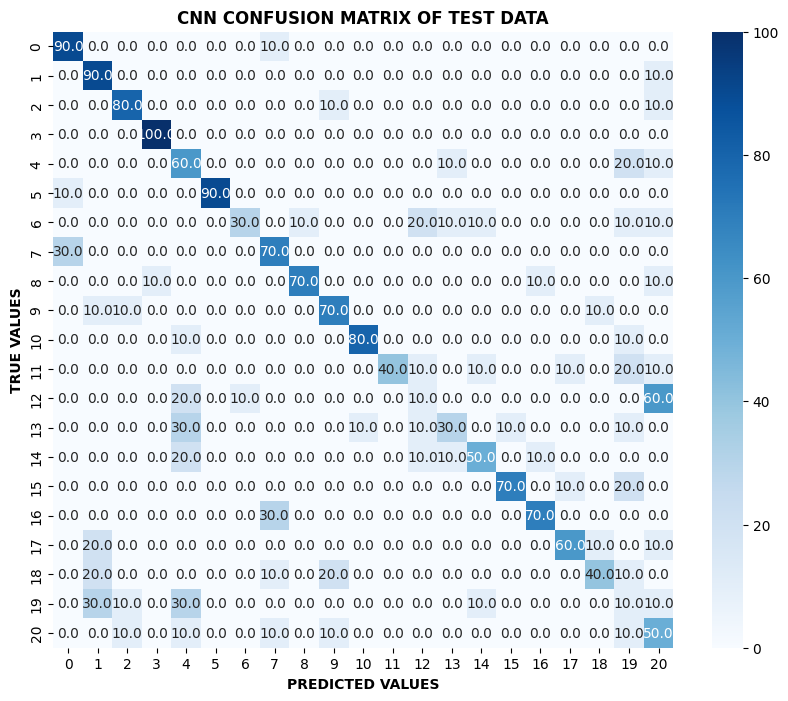

RESULTS OF CNN: 

Training Accuracy: 89.46428298950195

Validation Accuracy: 59.04762148857117

Test Accuracy: 60.00000238418579


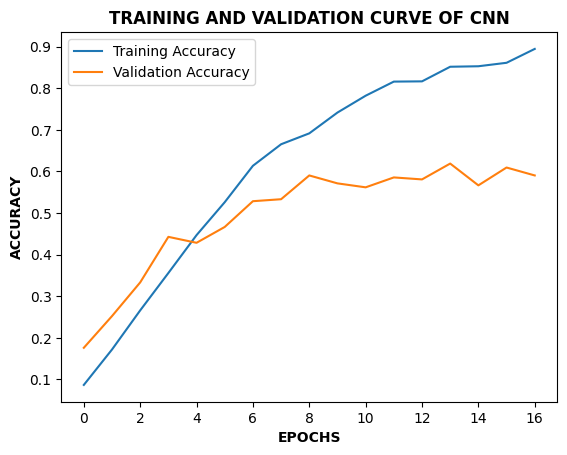

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#constructing a CNN model
CNN = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(61, 61, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(21, activation='softmax')
])

CNN.summary()

#compiling the model
CNN .compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Adding EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = CNN .fit(LandDataNorm_Train , LandLable_train, validation_data=(LandDataNorm_Val , LandLable_val), epochs=20, batch_size=32, callbacks=[early_stopping])

#accuracy of testing data
test_loss, test_acc = CNN .evaluate(LandDataNorm_Test ,  LandLable_test)
CNN_prediction = CNN .predict(LandDataNorm_Test).argmax(axis=1)

#creating a confusion matrix between truth values and predicted values
ConfMatrix = confusion_matrix(LandLable_test, CNN_prediction)

#converting the values of confusion matrix into percentage
ConfMatrix  = ConfMatrix .astype('float') / ConfMatrix .sum(axis=1)[:, np.newaxis] * 100
ConfMatrix  = np.nan_to_num(ConfMatrix , nan=0.0)

#visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(ConfMatrix , annot=True, fmt='.1f', cmap='Blues', xticklabels=np.unique(LandLable), yticklabels=np.unique(LandLable))
plt.xlabel('PREDICTED VALUES', fontweight='bold')
plt.ylabel('TRUE VALUES', fontweight='bold')
plt.title("CNN CONFUSION MATRIX OF TEST DATA", fontweight='bold')
plt.show()

#accuracy of training and validation data
train_acc = history.history['accuracy'][-1]*100
val_acc = history.history['val_accuracy'][-1]*100

#output the accuracy of training, validation and testing data
print("RESULTS OF CNN: ")
print("\nTraining Accuracy:", train_acc)
print("\nValidation Accuracy:", val_acc)
print("\nTest Accuracy:", test_acc * 100)

#visualize the training and validation curves of CNN
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('EPOCHS', fontweight='bold')
plt.ylabel('ACCURACY', fontweight='bold')
plt.legend()
plt.title('TRAINING AND VALIDATION CURVE OF CNN', fontweight='bold')
plt.show()
